# Descriptive and Diagnostic Analytics

##### This notebook explores synthetic transit rideshare performance over time, focusing on ridership, revenue, operating costs, and farebox recovery.

### Objectives
 - Analyze monthly ridership trends
 - Compare revenue against total operating cost
 - Evaluate farebox recovery over time
 - Break down major cost components
 - Compare performance across disruption and recovery periods

In [22]:
# Import the libraries used for data handling, plotting, and file paths.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
# Set the project root directory.
# Since this notebook is inside the notebooks folder, moving one level up
# points to the main project folder.
project_root = Path.cwd().parent


# Load the processed monthly master dataset.
df = pd.read_csv(project_root / "data" / "processed" / "rs_monthly_master.csv")

# Convert the year_month column into a proper datetime field for plotting.
# Adding "-01" creates a full date such as 2020-01-01.
df["date"] = pd.to_datetime(df["year_month"] + "-01")

# Display the first few rows to confirm the data loaded correctly.
df.head()

,year_month,year,month,boardings,service_hours,revenue,active_vehicles,avg_passengers_per_vehicle,avg_fare_per_boarding,fuel_cost,fuel_price_index,maintenance_cost,maintenance_event_count,insurance_cost,total_cost,farebox_recovery,cost_per_boarding,cost_per_service_hour,revenue_per_boarding,date
0,2020-01,2020,1,8064.0,1242.0,33221.25,40.0,201.60,4.19,12769.74,1.006,14815.71,4,6149.63,33735.08,0.9848,4.18,27.16,4.12,2020-01-01
1,2020-02,2020,2,7987.0,1305.0,32599.67,40.0,199.68,4.05,13680.44,1.046,15616.59,2,6155.49,35452.52,0.9195,4.44,27.17,4.08,2020-02-01
2,2020-03,2020,3,8596.0,1274.0,36173.09,39.0,220.41,4.09,13393.44,1.040,14575.71,4,6262.88,34232.03,1.0567,3.98,26.87,4.21,2020-03-01
3,2020-04,2020,4,3995.0,1135.0,16831.57,37.0,107.97,4.15,11175.80,1.051,20507.60,4,6364.83,38048.23,0.4424,9.52,33.52,4.21,2020-04-01
4,2020-05,2020,5,3080.0,1151.0,11991.75,36.0,85.56,4.13,10561.48,1.035,14071.70,4,6279.67,30912.85,0.3879,10.04,26.86,3.89,2020-05-01


In [24]:
# Display the dataset structure, column names, data types, and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   year_month                  84 non-null     str           
 1   year                        84 non-null     int64         
 2   month                       84 non-null     int64         
 3   boardings                   84 non-null     float64       
 4   service_hours               84 non-null     float64       
 5   revenue                     84 non-null     float64       
 6   active_vehicles             84 non-null     float64       
 7   avg_passengers_per_vehicle  84 non-null     float64       
 8   avg_fare_per_boarding       84 non-null     float64       
 9   fuel_cost                   84 non-null     float64       
 10  fuel_price_index            84 non-null     float64       
 11  maintenance_cost            84 non-null     float64       
 12  mainten

In [25]:
# Generate summary statistics for the numeric columns.
# This helps us understand ranges, averages, and spread of the data.
df.describe()

,year,month,boardings,service_hours,revenue,active_vehicles,avg_passengers_per_vehicle,avg_fare_per_boarding,fuel_cost,fuel_price_index,maintenance_cost,maintenance_event_count,insurance_cost,total_cost,farebox_recovery,cost_per_boarding,cost_per_service_hour,revenue_per_boarding,date
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84
mean,2023.000000,6.500000,6570.178571,1286.130952,27459.161310,39.690476,164.424048,4.174643,13415.385357,1.064750,15900.147143,3.226190,7184.257143,36499.789643,0.747577,5.942143,28.414881,4.175833,2023-06-16 21:08:34.285714
min,2020.000000,1.000000,2940.000000,1076.000000,11460.130000,35.000000,81.670000,4.050000,10369.280000,0.922000,12961.990000,2.000000,6149.630000,29990.250000,0.349400,3.980000,25.320000,3.860000,2020-01-01 00:00:00
25%,2021.000000,3.750000,5361.750000,1217.750000,22397.600000,39.000000,137.712500,4.137500,12310.362500,1.018000,14789.155000,2.000000,6633.050000,34151.300000,0.665000,4.930000,27.085000,4.107500,2021-09-23 12:00:00
50%,2023.000000,6.500000,7059.500000,1300.000000,29028.470000,40.000000,173.090000,4.180000,13558.250000,1.065000,15322.510000,3.000000,7240.885000,36512.020000,0.774250,5.435000,28.105000,4.180000,2023-06-16 00:00:00
75%,2025.000000,9.250000,7792.250000,1357.000000,32669.720000,41.000000,192.097500,4.212500,14755.192500,1.117000,16035.507500,4.000000,7686.525000,38816.370000,0.855925,6.297500,29.070000,4.270000,2025-03-08 18:00:00
max,2026.000000,12.000000,8761.000000,1461.000000,37382.970000,44.000000,220.410000,4.280000,16920.200000,1.216000,22004.490000,5.000000,8240.580000,43286.660000,1.056700,11.160000,34.270000,4.440000,2026-12-01 00:00:00
std,2.012012,3.472786,1624.889454,93.266657,6860.060414,1.926206,36.812128,0.055633,1701.145299,0.069636,1915.203432,0.909802,602.808754,3016.507943,0.165309,1.697851,1.847342,0.119024,NaN


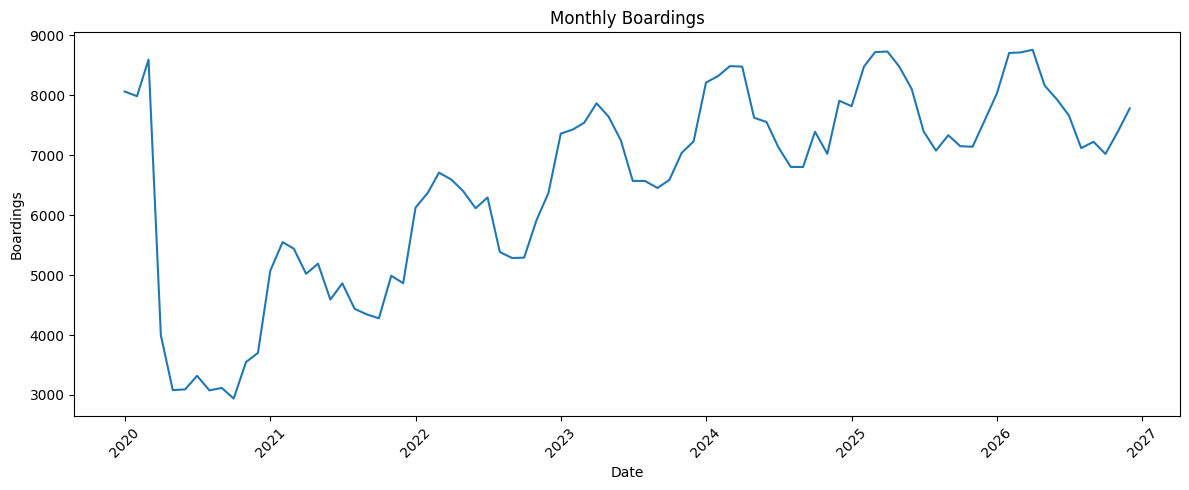

In [26]:
# Create a line chart showing monthly ridership over time.
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["boardings"])

# Add chart title and axis labels.
plt.title("Monthly Boardings")
plt.xlabel("Date")
plt.ylabel("Boardings")

# Rotate x-axis labels for readability.
plt.xticks(rotation=45)

# Adjust layout so labels fit properly.
plt.tight_layout()

# Display the chart.
plt.show()

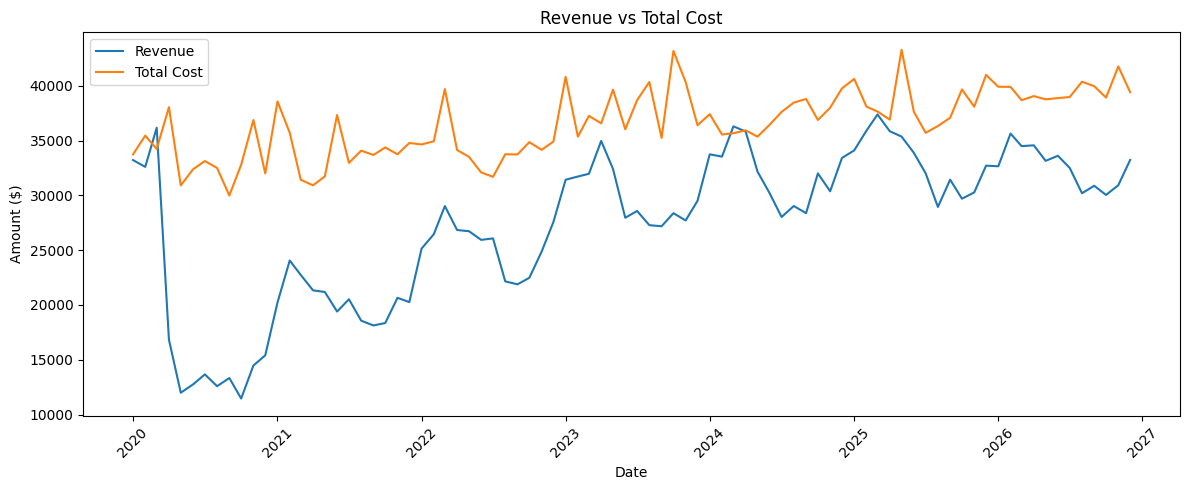

In [27]:
# Create a line chart comparing monthly revenue and total operating cost.
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["revenue"], label="Revenue")
plt.plot(df["date"], df["total_cost"], label="Total Cost")

# Add chart title and axis labels.
plt.title("Revenue vs Total Cost")
plt.xlabel("Date")
plt.ylabel("Amount ($)")

# Show legend to distinguish the two lines.
plt.legend()

# Rotate x-axis labels for readability.
plt.xticks(rotation=45)

# Adjust layout so labels fit properly.
plt.tight_layout()

# Display the chart.
plt.show()

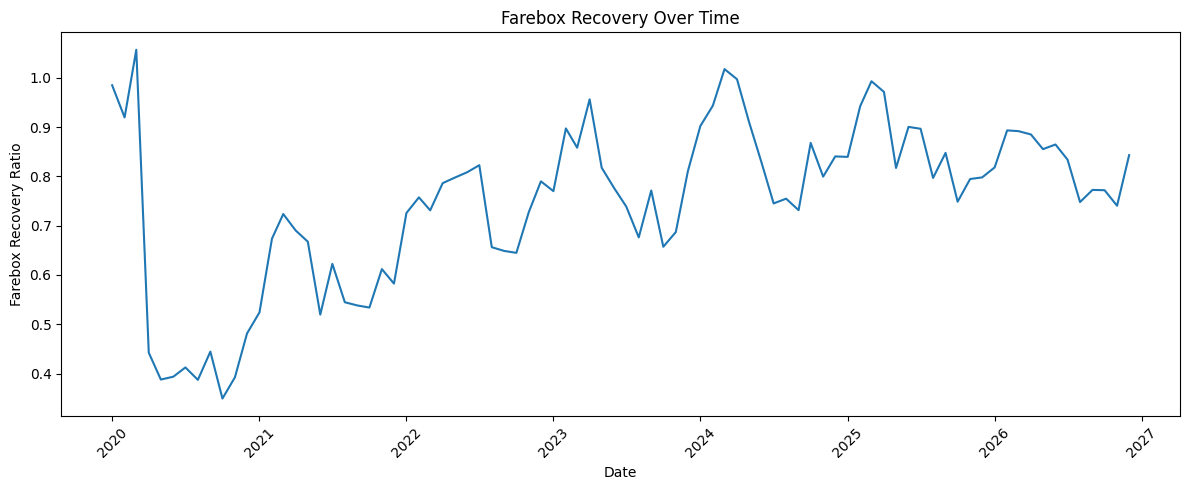

In [28]:
# Create a line chart showing how farebox recovery changes over time.
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["farebox_recovery"])

# Add chart title and axis labels.
plt.title("Farebox Recovery Over Time")
plt.xlabel("Date")
plt.ylabel("Farebox Recovery Ratio")

# Rotate x-axis labels for readability.
plt.xticks(rotation=45)

# Adjust layout so labels fit properly.
plt.tight_layout()

# Display the chart.
plt.show()

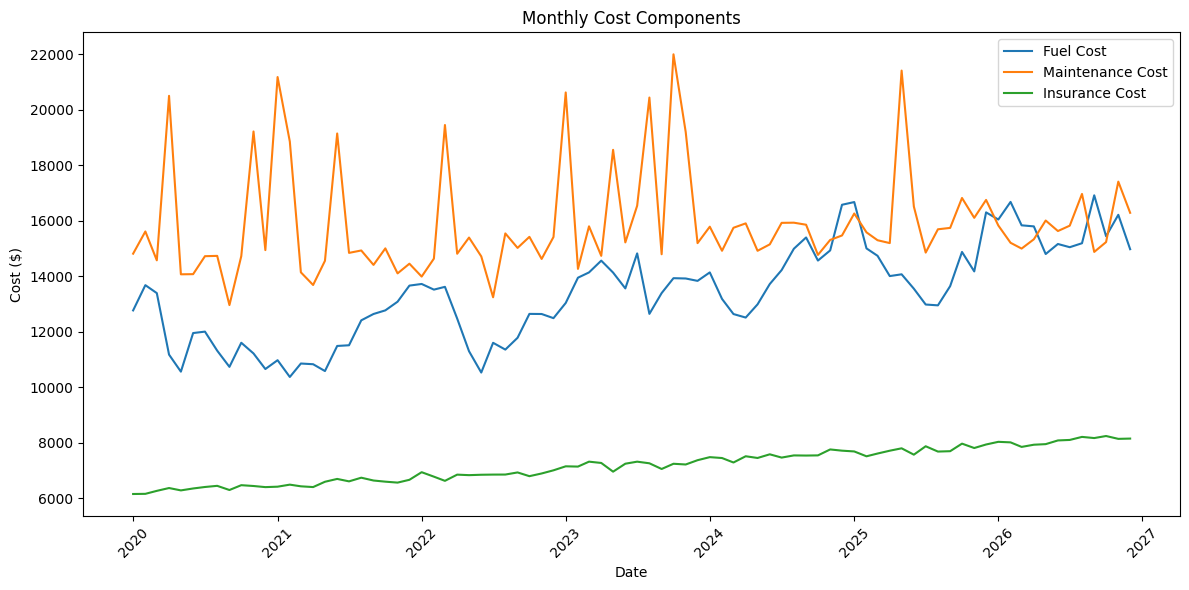

In [29]:
# Create a line chart to compare the three major monthly cost components.
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["fuel_cost"], label="Fuel Cost")
plt.plot(df["date"], df["maintenance_cost"], label="Maintenance Cost")
plt.plot(df["date"], df["insurance_cost"], label="Insurance Cost")

# Add chart title and axis labels.
plt.title("Monthly Cost Components")
plt.xlabel("Date")
plt.ylabel("Cost ($)")

# Show legend for the three cost categories.
plt.legend()

# Rotate x-axis labels for readability.
plt.xticks(rotation=45)

# Adjust layout so labels fit properly.
plt.tight_layout()

# Display the chart.
plt.show()

In [30]:
# Create a summary dictionary of key performance indicators across the full dataset.
summary = {
    "Total Boardings": round(df["boardings"].sum(), 0),
    "Total Revenue": round(df["revenue"].sum(), 2),
    "Total Cost": round(df["total_cost"].sum(), 2),
    "Average Farebox Recovery": round(df["farebox_recovery"].mean(), 3),
    "Average Cost per Boarding": round(df["cost_per_boarding"].mean(), 2),
    "Average Cost per Service Hour": round(df["cost_per_service_hour"].mean(), 2),
}

# Convert the dictionary into a small table for easier display.
summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

# Display the KPI summary table.
summary_df

,Metric,Value
0,Total Boardings,551895.000
1,Total Revenue,2306569.550
2,Total Cost,3065982.330
3,Average Farebox Recovery,0.748
4,Average Cost per Boarding,5.940
5,Average Cost per Service Hour,28.410


In [31]:
# Create a new column to group months into major operating periods.
df["period_group"] = "Stabilized"

# Label the earliest months as pre-disruption.
df.loc[df["date"] < "2020-04-01", "period_group"] = "Pre-Disruption"

# Label the disruption period.
df.loc[
    (df["date"] >= "2020-04-01") & (df["date"] <= "2020-12-01"),
    "period_group"
] = "Disruption"

# Label the multi-year recovery period.
df.loc[
    (df["date"] >= "2021-01-01") & (df["date"] <= "2023-12-01"),
    "period_group"
] = "Recovery"

# Calculate average values for key metrics within each period group.
period_summary = (
    df.groupby("period_group")[["boardings", "revenue", "total_cost", "farebox_recovery"]]
    .mean()
    .round(2)
)

# Display the period-level comparison table.
period_summary

,boardings,revenue,total_cost,farebox_recovery
period_group,,,,
Disruption,3319.11,13610.37,33181.76,0.41
Pre-Disruption,8215.67,33998.00,34473.21,0.99
Recovery,6029.89,25267.84,35592.49,0.71
Stabilized,7786.11,32567.78,38405.48,0.85


### Initial Insights

- Monthly boardings decline sharply during the disruption period and gradually recover afterward.
- Revenue generally follows the same pattern as boardings, while total cost remains more stable.
- Farebox recovery falls during low-ridership periods and improves as ridership returns.
- Maintenance costs are more volatile than insurance costs and include occasional spike months.
- Insurance cost remains relatively stable across the timeline and acts as a smoother cost component.

In [34]:
# Compare average performance across major operating periods.
period_summary = (
    df.groupby("period_group")[["boardings", "revenue", "total_cost", "farebox_recovery"]]
    .mean()
    .round(2)
)

period_summary

,boardings,revenue,total_cost,farebox_recovery
period_group,,,,
Disruption,3319.11,13610.37,33181.76,0.41
Pre-Disruption,8215.67,33998.00,34473.21,0.99
Recovery,6029.89,25267.84,35592.49,0.71
Stabilized,7786.11,32567.78,38405.48,0.85


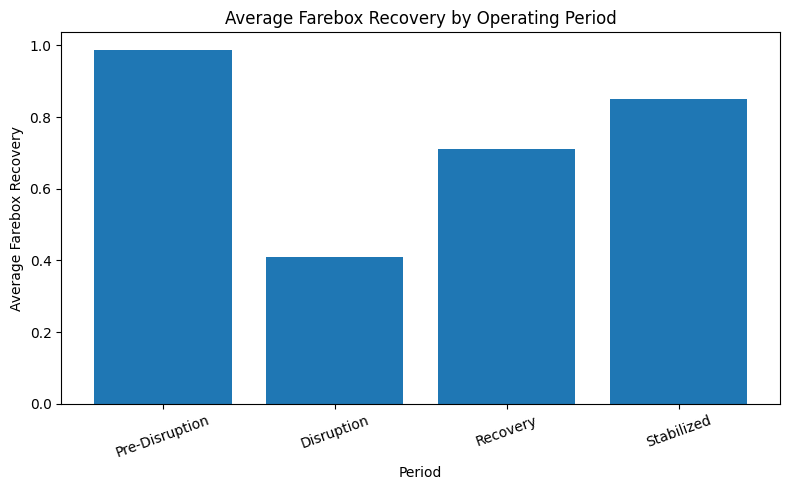

In [35]:
# Plot average farebox recovery by operating period.
period_farebox = (
    df.groupby("period_group")["farebox_recovery"]
    .mean()
    .reindex(["Pre-Disruption", "Disruption", "Recovery", "Stabilized"])
)

plt.figure(figsize=(8, 5))
plt.bar(period_farebox.index, period_farebox.values)
plt.title("Average Farebox Recovery by Operating Period")
plt.xlabel("Period")
plt.ylabel("Average Farebox Recovery")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
# Calculate total share of each cost component across the full timeline.
cost_share = pd.Series({
    "Fuel": df["fuel_cost"].sum(),
    "Maintenance": df["maintenance_cost"].sum(),
    "Insurance": df["insurance_cost"].sum(),
})

cost_share = (cost_share / cost_share.sum()).round(3)
cost_share

Fuel           0.368
Maintenance    0.436
Insurance      0.197
dtype: float64

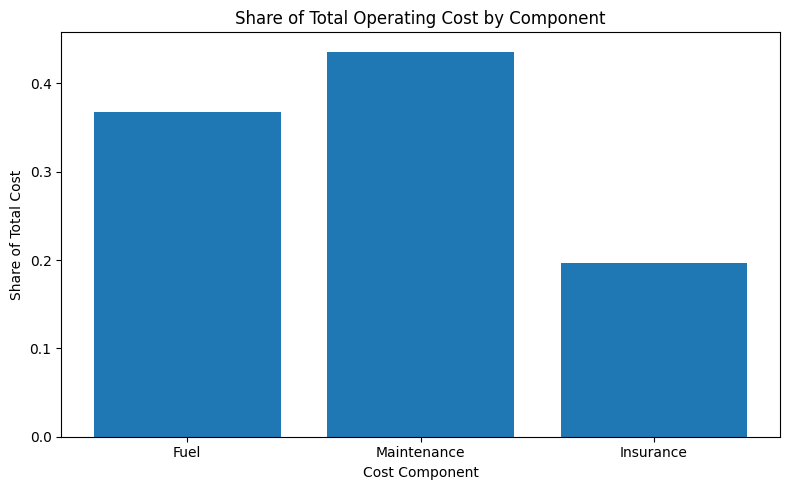

In [37]:
# Plot the share of each cost component.
plt.figure(figsize=(8, 5))
plt.bar(cost_share.index, cost_share.values)
plt.title("Share of Total Operating Cost by Component")
plt.xlabel("Cost Component")
plt.ylabel("Share of Total Cost")
plt.tight_layout()
plt.show()

### Key Insights

- Ridership and revenue declined sharply during the disruption period, then improved steadily during recovery.
- Total operating cost was more stable than revenue, which caused farebox recovery to weaken during low-demand periods.
- Farebox recovery improved meaningfully after 2021, but appears to level off in later years rather than continuing to rise indefinitely.
- Maintenance is the most volatile cost category, while insurance remains comparatively stable over time.
- The stabilization of farebox recovery suggests that future financial gains may require targeted pricing or cost-management actions rather than relying only on continued ridership recovery.

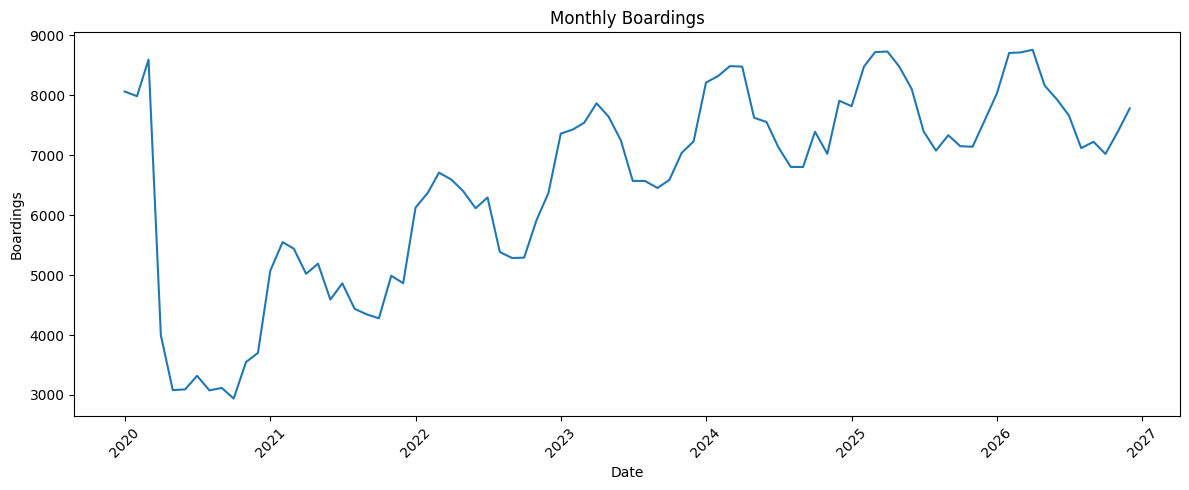

In [38]:
# Save the monthly boardings chart for documentation or README use.
output_path = project_root / "outputs" / "charts"
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["boardings"])
plt.title("Monthly Boardings")
plt.xlabel("Date")
plt.ylabel("Boardings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_path / "monthly_boardings.png", dpi=300, bbox_inches="tight")
plt.show()

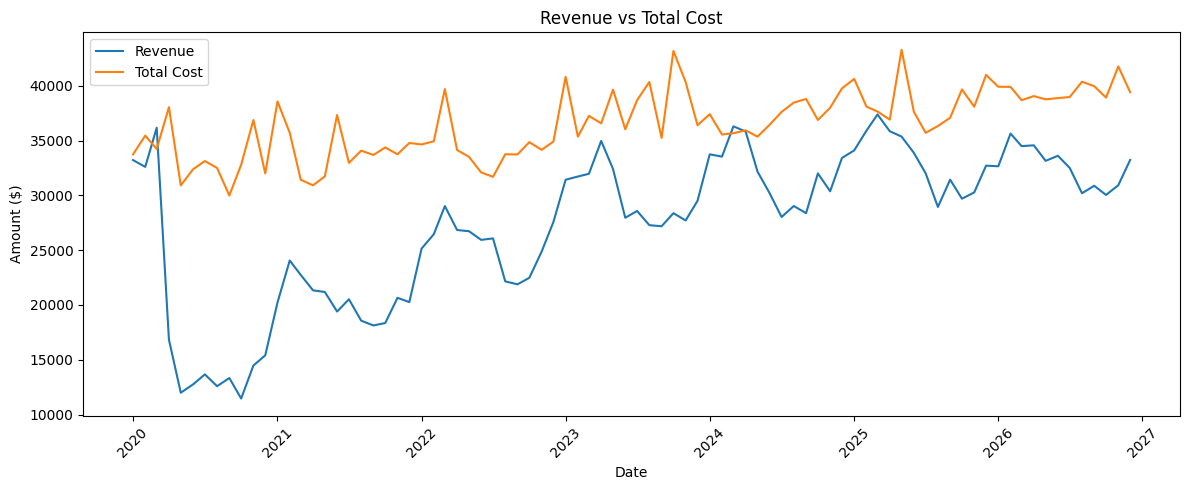

In [39]:
# Save the monthly boardings chart for documentation or README use.
output_path = project_root / "outputs" / "charts"
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["revenue"], label="Revenue")
plt.plot(df["date"], df["total_cost"], label="Total Cost")
plt.title("Revenue vs Total Cost")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

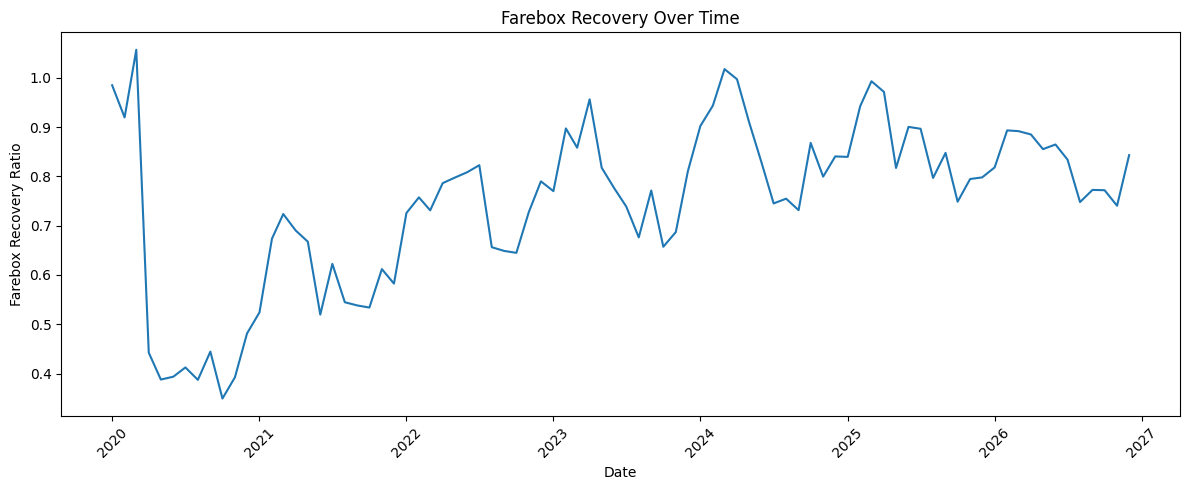

In [51]:
output_path = project_root / "outputs" / "charts"
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["farebox_recovery"])
plt.title("Farebox Recovery Over Time")
plt.xlabel("Date")
plt.ylabel("Farebox Recovery Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_path / "farebox_recovery.png", dpi=300, bbox_inches="tight")
plt.show()